# 07. Proyek 1: pencatatan eksperimen NLP

Membandingkan model melalui beberapa seed, mencatat konfigurasi dan waktu, memilih melalui validasi, serta membuka data uji setelah pemilihan.

**Prasyarat:** modul 06.

**Pola belajar:** baca penjelasan, prediksi bentuk keluaran, jalankan kode, lalu ubah satu hal.

Contoh ulasan dalam paket ini merupakan data sintetis untuk mempelajari mekanisme. Metriknya tidak mewakili kinerja pada ulasan nyata.

## Penyiapan

Instal dependensi melalui petunjuk README sebelum menjalankan seluruh sel. Setiap notebook dapat dimulai dengan kernel baru. GPU bersifat opsional. Semua operasi tensor yang berinteraksi harus berada pada perangkat yang sesuai.

In [1]:
from pathlib import Path
import sys
# Lokal: buka dari root repo, folder nlp, atau nlp/notebooks.
# Colab: ambil paket kursus jika belum tersedia.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for base in candidates for p in (base, base / "nlp")
             if (p / "nlp_course").is_dir()), None)
if ROOT is None and "google.colab" in sys.modules:
    import subprocess
    target = Path("/content/pytorch-deep-learning-nlp")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none",
                        "--sparse", "--branch", "nlp-learning-path",
                        "https://github.com/FeliksMakarios/pytorch-deep-learning.git",
                        str(target)], check=True)
        subprocess.run(["git", "sparse-checkout", "set", "nlp"], cwd=target, check=True)
    ROOT = target / "nlp"
if ROOT is None or not (ROOT / "nlp_course").is_dir():
    raise RuntimeError("Folder nlp_course tidak ditemukan. Ikuti petunjuk README nlp.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import torch
from torch import nn
from nlp_course.data import tokenize, build_vocab, encode, read_rows, loaders, collate_batch
from nlp_course.models import MeanClassifier, RecurrentClassifier, TinyTransformer
from nlp_course.engine import seed_all, fit, run_epoch, metrics, save_mean, load_mean, predict
seed_all(42)
torch.set_num_threads(1)
device = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
print("PyTorch:", torch.__version__, "Perangkat:", device)

PyTorch: 2.14.0+cu130 Perangkat: cpu


## 1. Menentukan pertanyaan eksperimen

Pertanyaan kita: apakah representasi urutan membantu dibanding rata-rata embedding pada data ini? Variabel yang diubah adalah keluarga model dan seed. Data, dimensi embedding, jumlah epoch, serta metrik dibuat eksplisit.

In [2]:
import time, json, statistics, hashlib
vocab,_,_,_ = loaders()
configs = [{"kind":kind,"seed":seed,"dim":16,"epochs":12,"lr":0.01}
           for kind in ["mean","lstm"] for seed in [7,42,99]]
print(configs)
data_hash = hashlib.sha256((ROOT/"data/reviews.csv").read_bytes()).hexdigest()

[{'kind': 'mean', 'seed': 7, 'dim': 16, 'epochs': 12, 'lr': 0.01}, {'kind': 'mean', 'seed': 42, 'dim': 16, 'epochs': 12, 'lr': 0.01}, {'kind': 'mean', 'seed': 99, 'dim': 16, 'epochs': 12, 'lr': 0.01}, {'kind': 'lstm', 'seed': 7, 'dim': 16, 'epochs': 12, 'lr': 0.01}, {'kind': 'lstm', 'seed': 42, 'dim': 16, 'epochs': 12, 'lr': 0.01}, {'kind': 'lstm', 'seed': 99, 'dim': 16, 'epochs': 12, 'lr': 0.01}]


## 2. Menjalankan dan mencatat validasi

Setiap eksperimen memakai model dan DataLoader baru. Waktu CPU yang dicatat membantu membandingkan biaya pada lingkungan yang sama. Angka waktu antarmesin tidak dapat dibandingkan langsung.

In [3]:
records,models = [],{}
for cfg in configs:
    seed_all(cfg["seed"])
    _,train,val,_ = loaders(vocab=vocab,seed=cfg["seed"])
    model = (MeanClassifier(len(vocab),dim=cfg["dim"]) if cfg["kind"]=="mean"
             else RecurrentClassifier(len(vocab),dim=cfg["dim"],hidden=16))
    start = time.perf_counter()
    history = fit(model,train,val,epochs=cfg["epochs"],lr=cfg["lr"])
    record = {**cfg,"seconds":time.perf_counter()-start,
              "parameters":sum(p.numel() for p in model.parameters()),
              "val":run_epoch(model,val),"data_sha256":data_hash,
              "torch":str(torch.__version__),"history":history}
    records.append(record)
    models[(cfg["kind"],cfg["seed"])] = model
    print(cfg["kind"],cfg["seed"],record["val"]["macro_f1"])
log_path = ARTIFACTS/"experiments.json"
log_path.write_text(json.dumps(records,indent=2),encoding="utf-8")

mean 7 0.5636363625526428
mean 42 0.681214451789856
mean 99 0.7333333492279053
lstm 7 1.0
lstm 42 1.0
lstm 99 0.9372549057006836
14645


## 3. Agregasi beberapa seed

Rata-rata merangkum kecenderungan. Simpangan baku menunjukkan variasi antarpercobaan, bukan interval kepercayaan yang otomatis sahih. Tiga seed masih merupakan sampel kecil.

In [4]:
summary = {}
for kind in ["mean","lstm"]:
    scores = [r["val"]["macro_f1"] for r in records if r["kind"]==kind]
    summary[kind] = {"mean_f1":statistics.mean(scores),"std_f1":statistics.stdev(scores)}
print(summary)

{'mean': {'mean_f1': 0.6593947211901346, 'std_f1': 0.08692722418350514}, 'lstm': {'mean_f1': 0.9790849685668945, 'std_f1': 0.03622589708403878}}


## 4. Visualisasi perbandingan

Gunakan sumbu dan label yang menyebut split. Diagram berikut menampilkan validasi, bukan kinerja uji. Jangan menyembunyikan variasi seed dengan hanya melaporkan percobaan terbaik.

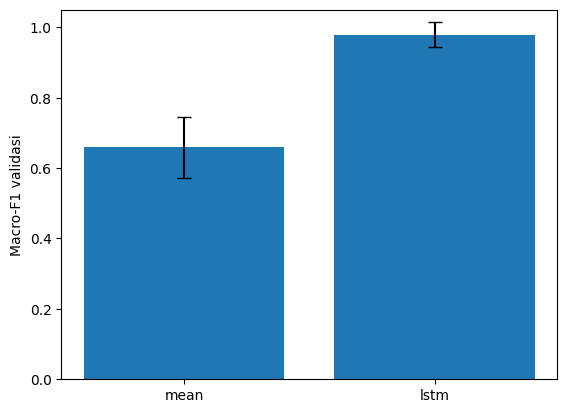

In [5]:
import matplotlib.pyplot as plt
names=list(summary)
plt.bar(names,[summary[k]["mean_f1"] for k in names],
        yerr=[summary[k]["std_f1"] for k in names],capsize=5)
plt.ylim(0,1.05)
plt.ylabel("Macro-F1 validasi")
plt.show()

## 5. Pemilihan keluarga dan evaluasi akhir

Pilih keluarga berdasarkan rata-rata validasi. Untuk checkpoint akhir demonstrasi, seed 42 sudah ditetapkan sebelumnya, sehingga kita tidak memilih seed terbaik. Setelah evaluasi uji, perubahan baru sebaiknya menggunakan protokol evaluasi baru yang disepakati.

In [6]:
chosen = max(summary,key=lambda name:summary[name]["mean_f1"])
final_model = models[(chosen,42)]
_,_,_,test = loaders(vocab=vocab)
final_result = {"chosen_family":chosen,"fixed_seed":42,"test":run_epoch(final_model,test)}
print(final_result)
(ARTIFACTS/"final_result.json").write_text(json.dumps(final_result,indent=2),encoding="utf-8")

{'chosen_family': 'lstm', 'fixed_seed': 42, 'test': {'loss': 0.001964669703738764, 'accuracy': 1.0, 'macro_f1': 1.0, 'confusion': [[48, 0], [0, 48]]}}
244


## Latihan mandiri

1. Mengapa seed terbaik tidak langsung dipilih?
2. Apa fungsi hash dataset?
3. Bagaimana menilai tambahan komputasi?
4. Apa keterbatasan tiga seed?

## Pembahasan latihan

1. Pemilihan seed terbaik dapat memberikan gambaran terlalu optimistis.
2. Hash membantu mendeteksi perubahan isi data antarpercobaan.
3. Bandingkan perubahan metrik, waktu, jumlah parameter, dan kebutuhan perangkat.
4. Variasi yang diamati belum tentu mewakili seluruh variasi proses pelatihan.

## Penghubung ke materi berikutnya

Modul 08 membuka mekanisme attention dan membangun classifier Transformer kecil.

### Rujukan
- [Dokumentasi PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Sumber Embedding](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/sparse.py)
- [Sumber Transformer](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py)
- [Kursus sumber dan struktur awal](https://github.com/mrdbourke/pytorch-deep-learning)

Materi ini ditulis sebagai jalur NLP mandiri. Penjelasan dan contoh NLP bukan terjemahan resmi kursus sumber.